<a href="https://colab.research.google.com/github/mhizbulloh/UTS-Citra-Digital-2026-IF24a-Semester-4/blob/main/Jawaban_Nomor2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

👇 Silakan klik tombol 'Choose Files' di bawah untuk memilih gambar dari perangkat Anda:


Saving TranscodedWallpaper (1) to TranscodedWallpaper (1)

✅ Memproses gambar: TranscodedWallpaper (1)

📊 Rata-rata Nilai Piksel:
Original : 44.16
LPF      : 44.15
HPF      : 4.46
BPF      : 44.33


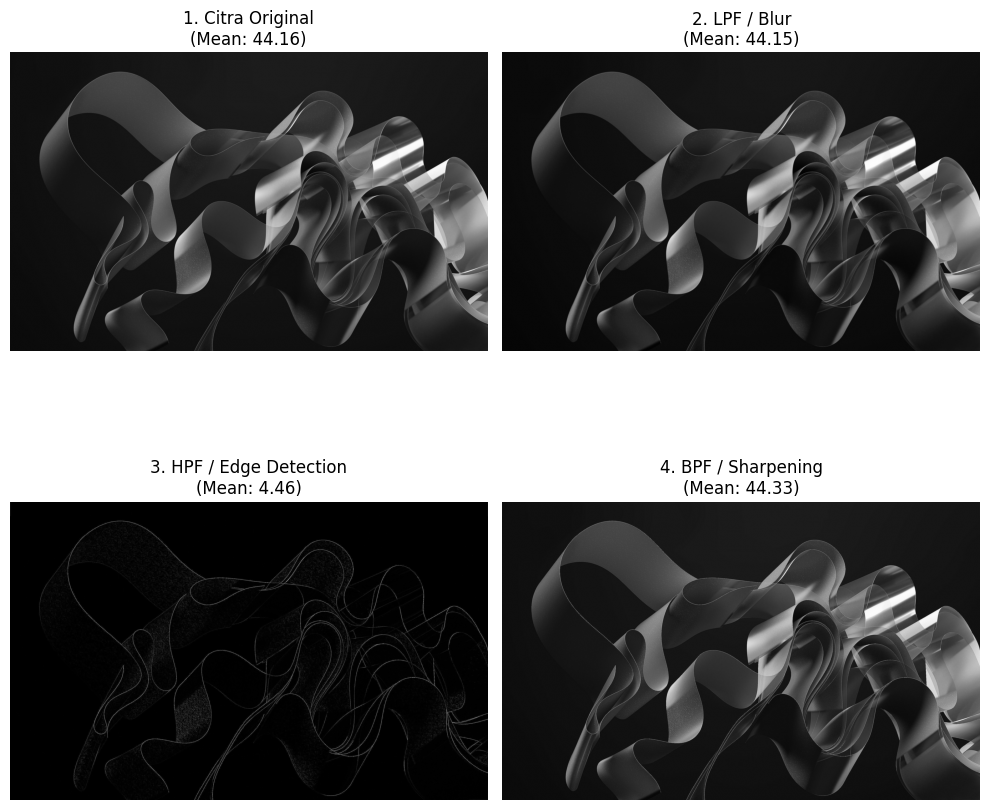


🎉 PROSES SOAL 2 SELESAI
1. Gambar Konvolusi telah berhasil ditampilkan.
2. File 'analisa_konvolusi.txt' telah berhasil dibuat dengan menyertakan nilai piksel dari foto Anda.
👉 Silakan buka menu folder (ikon 📁 di sebelah kiri Colab), lalu download 'analisa_konvolusi.txt' untuk di-upload ke GitHub.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Langkah 1: Meminta User Mengunggah Foto ---
print("👇 Silakan klik tombol 'Choose Files' di bawah untuk memilih gambar dari perangkat Anda:")
uploaded = files.upload()

if not uploaded:
    print("❌ ERROR: Anda belum memilih gambar apapun.")
else:
    # Mengambil nama file gambar yang baru saja diunggah
    image_path = list(uploaded.keys())[0]
    print(f"\n✅ Memproses gambar: {image_path}")

    # --- Langkah 2: Baca Citra Grayscale ---
    # Menggunakan grayscale agar perhitungan nilai rata-rata lebih mudah dianalisis
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("❌ ERROR: Gambar gagal dibaca.")
    else:
        # --- Langkah 3: Definisi 3 Kernel ---
        # 1. Low Pass Filter (LPF) - Reduksi noise / Blur
        kernel_lpf = np.array([[1, 1, 1],
                               [1, 1, 1],
                               [1, 1, 1]], dtype=np.float32) / 9.0

        # 2. High Pass Filter (HPF) - Deteksi tepi
        kernel_hpf = np.array([[-1, -1, -1],
                               [-1,  8, -1],
                               [-1, -1, -1]], dtype=np.float32)

        # 3. Band Pass Filter / High Boost (BPF/Sharpening) - Penajaman
        kernel_bpf = np.array([[ 0, -1,  0],
                               [-1,  5, -1],
                               [ 0, -1,  0]], dtype=np.float32)

        # --- Langkah 4: Terapkan Konvolusi (Filter2D) ---
        # ddepth = -1 berarti gambar output memiliki kedalaman/format yang sama dengan input
        img_lpf = cv2.filter2D(img, -1, kernel_lpf)
        img_hpf = cv2.filter2D(img, -1, kernel_hpf)
        img_bpf = cv2.filter2D(img, -1, kernel_bpf)

        # --- Langkah 5: Menghitung Rata-rata Nilai Piksel ---
        mean_ori = np.mean(img)
        mean_lpf = np.mean(img_lpf)
        mean_hpf = np.mean(img_hpf)
        mean_bpf = np.mean(img_bpf)

        print("\n📊 Rata-rata Nilai Piksel:")
        print(f"Original : {mean_ori:.2f}")
        print(f"LPF      : {mean_lpf:.2f}")
        print(f"HPF      : {mean_hpf:.2f}")
        print(f"BPF      : {mean_bpf:.2f}")

        # --- Langkah 6: Tampilkan Gambar dalam 1 Figure (2x2) ---
        fig, axes = plt.subplots(2, 2, figsize=(10, 10))

        axes[0, 0].imshow(img, cmap='gray')
        axes[0, 0].set_title(f'1. Citra Original\n(Mean: {mean_ori:.2f})')
        axes[0, 0].axis('off')

        axes[0, 1].imshow(img_lpf, cmap='gray')
        axes[0, 1].set_title(f'2. LPF / Blur\n(Mean: {mean_lpf:.2f})')
        axes[0, 1].axis('off')

        axes[1, 0].imshow(img_hpf, cmap='gray')
        axes[1, 0].set_title(f'3. HPF / Edge Detection\n(Mean: {mean_hpf:.2f})')
        axes[1, 0].axis('off')

        axes[1, 1].imshow(img_bpf, cmap='gray')
        axes[1, 1].set_title(f'4. BPF / Sharpening\n(Mean: {mean_bpf:.2f})')
        axes[1, 1].axis('off')

        plt.tight_layout()
        plt.show()

        # --- Langkah 7: Membuat file analisa.txt dengan Data Dinamis ---
        teks_analisa = f"""Analisa Konvolusi Citra (Soal 2) untuk file: {image_path}

1. Perbandingan Hasil Visual dan Nilai Piksel Rata-rata:
- Citra Original (Rata-rata Piksel: {mean_ori:.2f}): Menampilkan detail asli dari gambar.
- Citra LPF (Rata-rata Piksel: {mean_lpf:.2f}): Secara visual, gambar terlihat lebih blur/halus karena detail kecil dihilangkan. Nilai rata-ratanya hampir sama dengan citra asli karena total bobot kernel LPF adalah 1 (9/9).
- Citra HPF (Rata-rata Piksel: {mean_hpf:.2f}): Secara visual, gambar menjadi dominan gelap dan hanya menyisakan garis-garis tepi (edge) objek. Nilai rata-ratanya turun sangat drastis mendekati angka 0. Hal ini karena total bobot kernel HPF adalah 0 (8 - 8), sehingga area latar belakang yang warnanya sama akan dikalikan menjadi 0 (hitam).
- Citra BPF/Sharpening (Rata-rata Piksel: {mean_bpf:.2f}): Secara visual, gambar mempertahankan warna aslinya tetapi garis dan tepian objek menjadi lebih tajam. Nilai rata-ratanya mirip dengan citra original karena total bobot kernelnya adalah 1 (5 - 4).

2. Hubungan antara Domain Spasial dan Domain Frekuensi:
- Low Pass Filter (LPF): Dalam domain spasial, LPF merata-rata piksel dengan tetangganya. Dalam domain frekuensi, filter ini meloloskan frekuensi rendah (area dengan perubahan warna lambat seperti background) dan memblokir frekuensi tinggi (detail tajam dan noise).
- High Pass Filter (HPF): Dalam domain spasial, HPF mencari selisih besar antara piksel tengah dan tetangganya. Dalam domain frekuensi, HPF kebalikan dari LPF; meloloskan frekuensi tinggi (perubahan warna mendadak/tepi) dan memblokir frekuensi rendah (area polos jadi hitam).
- Band Pass Filter (BPF) / Sharpening: Dalam domain spasial, filter ini adalah kombinasi dari Citra Original ditambah hasil HPF. Dalam domain frekuensi, filter ini meloloskan rentang frekuensi tertentu atau memberikan penguatan (boosting) pada frekuensi tinggi, sehingga citra tetap terlihat wujudnya namun tepinya makin tegas.
"""
        with open("analisa_konvolusi.txt", "w") as file:
            file.write(teks_analisa)

        print("\n🎉 PROSES SOAL 2 SELESAI")
        print("1. Gambar Konvolusi telah berhasil ditampilkan.")
        print("2. File 'analisa_konvolusi.txt' telah berhasil dibuat dengan menyertakan nilai piksel dari foto Anda.")
        print("👉 Silakan buka menu folder (ikon 📁 di sebelah kiri Colab), lalu download 'analisa_konvolusi.txt' untuk di-upload ke GitHub.")